In [ ]:
# Remove TF to resolve protobuf conflict with mediapipe
!pip uninstall -y tensorflow tensorflow-text tf-keras

# Install what the tennis pipeline actually needs
!pip install -q -U mediapipe opencv-python-headless tqdm
!pip install -q -U xgboost scikit-learn lightgbm catboost

# Skip shap and ydata-profiling — both demand numpy versions that conflict
# with mediapipe's pins. Use them in a separate notebook if needed.

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorflow-text 2.20.1
Uninstalling tensorflow-text-2.20.1:
  Successfully uninstalled tensorflow-text-2.20.1
Found existing installation: tf_keras 2.20.0
Uninstalling tf_keras-2.20.0:
  Successfully uninstalled tf_keras-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, which is not installed.
keras-hub 0.26.0 requires tensorflow-text; platform_system != "Windows", which is not installed.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, which

In [ ]:
!pip install -q "mediapipe==0.10.21"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 758.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, which is not installed.
keras-hub 0.26.0 requires tensorflow-text; platform_system != "Windows", which is not installed.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
dopamine-rl 4.1.2 requires tf-keras>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Tennis AI Coach (Google Colab)

Upload `.mov` or `.mp4` video of Logan playing tennis, run AI pose tracking (MediaPipe), extract simple technique metrics, generate **coaching suggestions** upon AI tool, and download results e.g., CSV, annotated video and report.

**What we get from the outputs**
1.`metrics.csv`: per-frame body metrics include knee bend, elbow angle, torso lean, stance width and wrist speed.
2.`strokes.csv`: automatically detected "swing momoents" based on your wrist-speed peaks.
3.`annotated_video.mp4`: your video with pose skeleton overlay plus key numbers.
4.`report.md` readable coaching report

**Privacy** Everrthing runs inside your Colab runtime. Nothing is uploadede anywhere unless we upload or share it. And we want to package it into a AI app/software that can be downloadable.

**Limitations** This is 2D pose estimation from a single camera angle. It is best for general cues such as knees, posture and balance, not fine-grained racket biomechanics.

In [ ]:
# 1) Install necessary dependences again

In [ ]:
import os
import cv2
import numpy as np
import mediapipe as mp

print("mediapipe version:", getattr(mp, "__version__", "N/A"))
print("mediapipe file:", getattr(mp, "__file__", "N/A"))
print("has solutions:", hasattr(mp, "solutions"))
print("top attrs:", [x for x in dir(mp) if not x.startswith("_")][:30])

mediapipe version: 0.10.21
mediapipe file: /usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
has solutions: True
top attrs: ['CalculatorGraph', 'GraphInputStreamAddMode', 'Image', 'ImageFormat', 'ImageFrame', 'Matrix', 'Packet', 'Timestamp', 'ValidatedGraphConfig', 'calculators', 'model_ckpt_util', 'packet_creator', 'packet_getter', 'resource_util', 'solutions', 'tasks']


In [ ]:
# 2) imports and write helper utilities functions
import os, math, json, textwrap, subprocess, shutil, zipfile
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import cv2
# import mediapipe as mp

from IPython.display import Markdown, display

# mp_pose = mp.solutions_pose
# mp_drawing = mp.solutions.drawing_utils

import mediapipe as mp

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

def ensure_dir(path: str) -> str:
  os.makedirs(path, exist_ok=True)
  return path

def run_cmd(cmd: List[str]) -> None:
  """Run a shell command and raise if it fails"""
  p = subprocess.run(cmd,stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
  if p.returncode != 0:
    raise RuntimeError(f"Command failed: {' '.join(cmd)}\n\n{p.stdout}")

def convert_to_mp4_if_needed(video_path: str, out_dir: str) -> str:
  """Convert .mov or other video to mp4 using ffmpeg for better OpenCV compatibility"""
  ext = os.path.splitext(video_path)[1].lower()
  if ext in [".mp4", ".m4v"]:
    return video_path

  out_path = os.path.join(out_dir, os.path.splitext(os.path.basename(video_path))[0]+ "_converted.mp4")
  # -y overwrite: -pix_fmt yuv420p for broad compatibility
  run_cmd([
      "ffmpeg","-y","-i", video_path,
      "-c:v", "libx264", "-preset", "veryfast", "-crf", "22", "-pix_fmt", "yuv420p",
      "-c:a", "aac", "-b:a", "128k",
      out_path
  ])
  return out_path

def angle_deg(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
  """
  Angle at point b formed by points a-b-c in degrees.
  Returns NaN if any point is missing.
  """
  if a is None or b is None or c is None:
    return float("nan")
  ba = a - b
  bc = c - b
  denom = (np.linalg.norm(ba) * np.linalg.norm(bc))
  if denom < 1e-9:
    return float("nan")
  cosang = float(np.clip(np.dot(ba, bc)/ denom, -1.0, 1.0))
  return float(np.degrees(np.arccos(cosang)))

def safe_norm(v: np.ndarray) -> float:
  return float(np.linalg.norm(v)) if v is not None else float("nan")

def signed_angle_from_vertical_deg(vec: np.ndarray) -> float:
  """
  Signed lean angle from vertical (degrees).
  vec is in image coordinates (x right, y down). Vertical "up" is (0, -1).
  Positive means leaning to the right of the image, negative to the left.
  """
  if vec is None or safe_norm(vec) < 1e-9:
    return float("nan")
  return float(np.degrees(np.arctan2(vec[0], -vec[1])))

# def tilt_from_horizontal_deg(vec: np.ndarray) -> float:
#   """Tilt angle relative to horizontal axis, degrees."""
#   if x is None or (isinstance(x,float) and (math.isnan(x) or math.isinf(x))):
#     return "n/a"
#   return f"{x:.{nd}f}"

def tilt_from_horizontal_deg(vec: np.ndarray) -> float:
  """Tilt angle relative to horizontal axis, degrees."""
  if vec is None or safe_norm(vec) < 1e-9:
    return float("nan")
  return float(np.degrees(np.arctan2(vec[1], vec[0])))

def fmt(x, nd=1) -> str:
  """Format a number for overlay text."""
  if x is None or (isinstance(x, float) and (math.isnan(x) or math.isinf(x))):
    return "n/a"
  return f"{x:.{nd}f}"

# def tilt_from_horizontal_deg(vec: np.ndarray) -> float:
#   """Tilt angle relative to horizontal axis, degrees."""
#   if vec is None or len(vec) != 2:
#     return np.nan

#   x, y =vec

#   if any([
#       x is None, y is None,
#       isinstance(x, float) and (math.isnan(x) or math.isinf(x)),
#       isinstance(y, float) and (math.isnan(y) or math.isinf(y))
#   ]):
#     return np.nan



In [ ]:
# 3) Upload tennis video (.mov/.mp4)
from google.colab import files

uploaded = files.upload()

if not uploaded:
  raise RuntimeError("No file was provided. Please upload a .mov or .mp4 video.")

input_video_path = next(iter(uploaded.keys()))
print("Uploaded:", input_video_path)

Saving IMG_7145.MOV to IMG_7145.MOV
Uploaded: IMG_7145.MOV


In [ ]:
# 4) Set output folder + convert video to mp4 (recommended)
OUT_DIR = ensure_dir("tennis_ai_outputs")
video_path = convert_to_mp4_if_needed(input_video_path, OUT_DIR)
print("Using video:", video_path)

Using video: tennis_ai_outputs/IMG_7145_converted.mp4


In [ ]:
# 5) Pose-based video analysis (AI) -> per-frame metrics + optional annotated video

@dataclass
class AnalysisConfig:
    sample_stride: int = 2           # process every Nth frame (2 = ~2x faster, less detail)
    max_frames: Optional[int] = None # set to e.g. 1500 to cap runtime
    min_det_conf: float = 0.5
    min_track_conf: float = 0.5
    model_complexity: int = 1        # 0/1/2 (higher = slower, sometimes more stable)
    annotate_video: bool = True

def _lm_xy(lm, idx: int, w: int, h: int) -> np.ndarray:
    return np.array([lm[idx].x * w, lm[idx].y * h], dtype=np.float32)

def analyze_video(video_path: str, out_dir: str, cfg: AnalysisConfig) -> Tuple[pd.DataFrame, Dict]:
    ensure_dir(out_dir)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(
            "OpenCV could not open the video. "
            "If you uploaded .mov, ensure conversion ran successfully."
        )

    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or fps <= 1e-6:
        fps = 30.0

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    dt = (1.0 / fps) * cfg.sample_stride

    annotated_path = os.path.join(out_dir, "annotated_video.mp4")
    writer = None
    if cfg.annotate_video:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(annotated_path, fourcc, fps / cfg.sample_stride, (w, h))

    pose = mp_pose.Pose(
        static_image_mode=False,
        model_complexity=cfg.model_complexity,
        enable_segmentation=False,
        min_detection_confidence=cfg.min_det_conf,
        min_tracking_confidence=cfg.min_track_conf,
    )

    L = mp_pose.PoseLandmark

    prev_pts = {
        "LEFT_WRIST": None,
        "RIGHT_WRIST": None,
    }

    rows = []
    frame_i = -1
    processed = 0

    pbar_total = total_frames if total_frames > 0 else None
    pbar = tqdm(total=pbar_total, desc="Processing frames")

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_i += 1
        pbar.update(1)

        if frame_i % cfg.sample_stride != 0:
            continue

        t = frame_i / fps

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = pose.process(rgb)

        # Defaults
        left_knee = right_knee = float("nan")
        left_elbow = right_elbow = float("nan")
        torso_lean = float("nan")
        shoulder_tilt = float("nan")
        hip_tilt = float("nan")
        stance_ratio = float("nan")

        lw_speed = rw_speed = float("nan")

        if res.pose_landmarks:
            lm = res.pose_landmarks.landmark

            # Keypoints
            l_sh = _lm_xy(lm, L.LEFT_SHOULDER.value, w, h)
            r_sh = _lm_xy(lm, L.RIGHT_SHOULDER.value, w, h)
            l_hp = _lm_xy(lm, L.LEFT_HIP.value, w, h)
            r_hp = _lm_xy(lm, L.RIGHT_HIP.value, w, h)

            l_kn = _lm_xy(lm, L.LEFT_KNEE.value, w, h)
            r_kn = _lm_xy(lm, L.RIGHT_KNEE.value, w, h)
            l_an = _lm_xy(lm, L.LEFT_ANKLE.value, w, h)
            r_an = _lm_xy(lm, L.RIGHT_ANKLE.value, w, h)

            l_el = _lm_xy(lm, L.LEFT_ELBOW.value, w, h)
            r_el = _lm_xy(lm, L.RIGHT_ELBOW.value, w, h)
            l_wr = _lm_xy(lm, L.LEFT_WRIST.value, w, h)
            r_wr = _lm_xy(lm, L.RIGHT_WRIST.value, w, h)

            # Angles
            left_knee = angle_deg(l_hp, l_kn, l_an)
            right_knee = angle_deg(r_hp, r_kn, r_an)

            left_elbow = angle_deg(l_sh, l_el, l_wr)
            right_elbow = angle_deg(r_sh, r_el, r_wr)

            # Torso lean (shoulder center vs hip center)
            sh_c = 0.5 * (l_sh + r_sh)
            hp_c = 0.5 * (l_hp + r_hp)
            torso_vec = sh_c - hp_c
            torso_lean = signed_angle_from_vertical_deg(torso_vec)

            # Shoulder tilt (line between shoulders)
            shoulder_vec = r_sh - l_sh
            shoulder_tilt = tilt_from_horizontal_deg(shoulder_vec)

            # Hip tilt (line between hips)
            hip_vec = r_hp - l_hp
            hip_tilt = tilt_from_horizontal_deg(hip_vec)

            # Stance width ratio: ankle distance vs hip distance (scale-invariant-ish)
            ankle_dist = safe_norm(r_an - l_an)
            hip_dist = safe_norm(r_hp - l_hp)
            stance_ratio = float(ankle_dist / (hip_dist + 1e-6)) if not math.isnan(ankle_dist) and not math.isnan(hip_dist) else float("nan")

            # Wrist speeds (pixels/sec)
            if prev_pts["LEFT_WRIST"] is not None:
                lw_speed = float(np.linalg.norm(l_wr - prev_pts["LEFT_WRIST"]) / dt)
            if prev_pts["RIGHT_WRIST"] is not None:
                rw_speed = float(np.linalg.norm(r_wr - prev_pts["RIGHT_WRIST"]) / dt)

            prev_pts["LEFT_WRIST"] = l_wr
            prev_pts["RIGHT_WRIST"] = r_wr

            if writer is not None:
                # Draw skeleton
                mp_drawing.draw_landmarks(frame, res.pose_landmarks, mp_pose.POSE_CONNECTIONS)

                # Overlay a few key metrics
                overlay = (
                    f"t={t:.2f}s | knee(L/R)={fmt(left_knee)}/{fmt(right_knee)} deg | "
                    f"lean={fmt(torso_lean)} deg | stance={fmt(stance_ratio)} | "
                    f"wristspd(L/R)={fmt(lw_speed,0)}/{fmt(rw_speed,0)} px/s"
                )
                cv2.putText(frame, overlay, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 4, cv2.LINE_AA)
                cv2.putText(frame, overlay, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1, cv2.LINE_AA)

                writer.write(frame)

        rows.append({
            "time_s": t,
            "frame_i": frame_i,
            "left_knee_angle_deg": left_knee,
            "right_knee_angle_deg": right_knee,
            "left_elbow_angle_deg": left_elbow,
            "right_elbow_angle_deg": right_elbow,
            "torso_lean_deg": torso_lean,          # signed
            "torso_lean_abs_deg": abs(torso_lean) if not math.isnan(torso_lean) else float("nan"),
            "shoulder_tilt_deg": shoulder_tilt,
            "hip_tilt_deg": hip_tilt,
            "stance_width_ratio": stance_ratio,
            "left_wrist_speed_px_s": lw_speed,
            "right_wrist_speed_px_s": rw_speed,
        })

        processed += 1
        if cfg.max_frames is not None and processed >= cfg.max_frames:
            break

    pbar.close()
    cap.release()
    if writer is not None:
        writer.release()

    df = pd.DataFrame(rows)

    meta = {
        "video_path": video_path,
        "fps": fps,
        "width": w,
        "height": h,
        "total_frames_reported": total_frames,
        "processed_frames": processed,
        "sample_stride": cfg.sample_stride,
        "annotated_video": annotated_path if cfg.annotate_video else None,
    }
    return df, meta

cfg = AnalysisConfig(
    sample_stride=2,
    max_frames=None,
    annotate_video=True,
)

metrics_df, meta = analyze_video(video_path, OUT_DIR, cfg)

print("Done.")
print(json.dumps(meta, indent=2))
print("\\nmetrics_df shape:", metrics_df.shape)
metrics_df.head()

Processing frames: 100%|██████████| 352/352 [00:42<00:00,  8.36it/s]


Done.
{
  "video_path": "tennis_ai_outputs/IMG_7145_converted.mp4",
  "fps": 30.0,
  "width": 3840,
  "height": 2160,
  "total_frames_reported": 352,
  "processed_frames": 176,
  "sample_stride": 2,
  "annotated_video": "tennis_ai_outputs/annotated_video.mp4"
}
\nmetrics_df shape: (176, 13)


,time_s,frame_i,left_knee_angle_deg,right_knee_angle_deg,left_elbow_angle_deg,right_elbow_angle_deg,torso_lean_deg,torso_lean_abs_deg,shoulder_tilt_deg,hip_tilt_deg,stance_width_ratio,left_wrist_speed_px_s,right_wrist_speed_px_s
0,0.000000,0,178.603523,178.071968,79.235903,103.877923,0.647802,0.647802,177.317093,-179.672562,1.556824,NaN,NaN
1,0.066667,2,179.118178,177.705607,82.217559,105.556067,-0.714670,0.714670,177.924652,-179.426636,1.551152,39.882892,26.959013
2,0.133333,4,180.000000,177.685140,75.043204,103.510988,-2.743017,2.743017,177.370300,179.496246,1.536389,145.070143,90.940146
3,0.200000,6,178.657974,177.431735,66.719077,100.443089,-4.410091,4.410091,176.825851,178.472580,1.569025,165.688162,212.672954
4,0.266667,8,176.325283,178.140063,59.754779,98.913682,-5.994555,5.994555,175.063995,176.208237,1.645500,208.304157,193.069797


In [ ]:
# 6) Detect swing moments (simple heuristic) + computer per-stroke summaries
def pick_hitting_arm(metrics_df: pd.DataFrame) -> str:
    """Choose the wrist with higher typical speed as the likely hitting arm."""
    l = metrics_df["left_wrist_speed_px_s"].replace([np.inf, -np.inf], np.nan).dropna()
    r = metrics_df["right_wrist_speed_px_s"].replace([np.inf, -np.inf], np.nan).dropna()
    if len(l) == 0 and len(r) == 0:
        return "RIGHT"
    l90 = np.nanpercentile(l, 90) if len(l) else -1
    r90 = np.nanpercentile(r, 90) if len(r) else -1
    return "LEFT" if l90 > r90 else "RIGHT"

def detect_peaks_1d(y: np.ndarray, thresh: float, min_gap: int) -> List[int]:
    """Small dependency-free peak detector for local maxima."""
    peaks = []
    for i in range(1, len(y) - 1):
        if not np.isfinite(y[i]):
            continue
        if y[i] > thresh and y[i] >= y[i-1] and y[i] >= y[i+1]:
            if not peaks or (i - peaks[-1]) >= min_gap:
                peaks.append(i)
            else:
                # If too close, keep the larger one
                if y[i] > y[peaks[-1]]:
                    peaks[-1] = i
    return peaks

def build_strokes_df(metrics_df: pd.DataFrame, fps: float, sample_stride: int) -> Tuple[pd.DataFrame, str, float]:
    hitting_arm = pick_hitting_arm(metrics_df)
    speed_col = "left_wrist_speed_px_s" if hitting_arm == "LEFT" else "right_wrist_speed_px_s"

    speed = metrics_df[speed_col].to_numpy(dtype=float)
    speed = np.nan_to_num(speed, nan=0.0, posinf=0.0, neginf=0.0)

    # Dynamic threshold based on speed distribution
    p95 = float(np.percentile(speed, 95)) if len(speed) else 0.0
    thresh = max(300.0, 0.35 * p95)  # px/s; tweak if needed for your camera distance
    min_gap = int(round(0.45 * fps / sample_stride))  # at least ~0.45s apart

    peaks = detect_peaks_1d(speed, thresh=thresh, min_gap=min_gap)

    # Summaries around each peak
    win_s = 0.25  # +/- window seconds
    win = int(round(win_s * fps / sample_stride))

    rows = []
    for j, p in enumerate(peaks, start=1):
        a = max(0, p - win)
        b = min(len(metrics_df) - 1, p + win)

        seg = metrics_df.iloc[a:b+1]

        # Knee bend: take the more-bent knee at each frame, then minimum in segment
        knee_min = np.nanmin(np.nanmin(np.vstack([
            seg["left_knee_angle_deg"].to_numpy(),
            seg["right_knee_angle_deg"].to_numpy(),
        ]), axis=0))

        stance_med = float(np.nanmedian(seg["stance_width_ratio"].to_numpy()))
        lean_abs_med = float(np.nanmedian(seg["torso_lean_abs_deg"].to_numpy()))

        if hitting_arm == "LEFT":
            elbow_med = float(np.nanmedian(seg["left_elbow_angle_deg"].to_numpy()))
        else:
            elbow_med = float(np.nanmedian(seg["right_elbow_angle_deg"].to_numpy()))

        rows.append({
            "stroke_id": j,
            "peak_time_s": float(metrics_df.iloc[p]["time_s"]),
            "peak_frame_i": int(metrics_df.iloc[p]["frame_i"]),
            "hitting_arm_guess": hitting_arm,
            "peak_speed_px_s": float(speed[p]),
            "min_knee_angle_deg": float(knee_min),
            "stance_width_ratio_med": stance_med,
            "torso_lean_abs_deg_med": lean_abs_med,
            "hitting_elbow_angle_deg_med": elbow_med,
        })

    strokes_df = pd.DataFrame(rows)
    return strokes_df, hitting_arm, thresh

strokes_df, hitting_arm, peak_thresh = build_strokes_df(metrics_df, meta["fps"], meta["sample_stride"])

print(f"Hitting arm guess: {hitting_arm}")
print(f"Peak threshold used: {peak_thresh:.0f} px/s")
print(f"Detected strokes: {len(strokes_df)}")
strokes_df.head(10)

Hitting arm guess: RIGHT
Peak threshold used: 688 px/s
Detected strokes: 9


,stroke_id,peak_time_s,peak_frame_i,hitting_arm_guess,peak_speed_px_s,min_knee_angle_deg,stance_width_ratio_med,torso_lean_abs_deg_med,hitting_elbow_angle_deg_med
0,1,2.466667,74,RIGHT,4294.109344,101.956233,4.522352,10.294310,105.489863
1,2,3.000000,90,RIGHT,1050.297432,139.834695,12.729670,2.086254,29.139049
2,3,3.733333,112,RIGHT,1060.422935,129.457593,2.423579,2.030791,87.185758
3,4,5.933333,178,RIGHT,993.020897,158.569074,0.903878,7.535839,112.134151
4,5,6.466667,194,RIGHT,2463.606033,154.473048,3.263765,8.787826,99.369808
5,6,6.933333,208,RIGHT,4466.779633,151.226655,3.590604,5.987206,117.492650
6,7,8.133333,244,RIGHT,995.169525,136.760423,2.187945,2.615785,93.973162
7,8,10.533333,316,RIGHT,3802.632980,142.363843,3.356276,2.918218,88.094251
8,9,11.600000,348,RIGHT,1249.436302,135.047494,10.974086,5.511912,117.738342


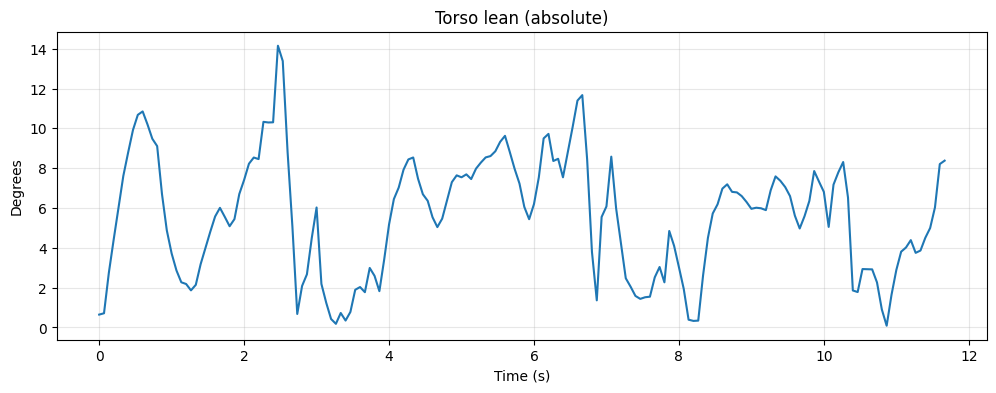

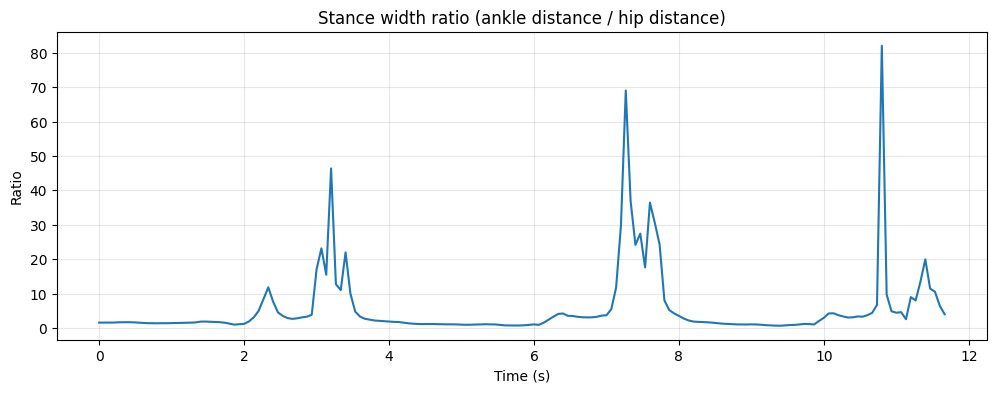

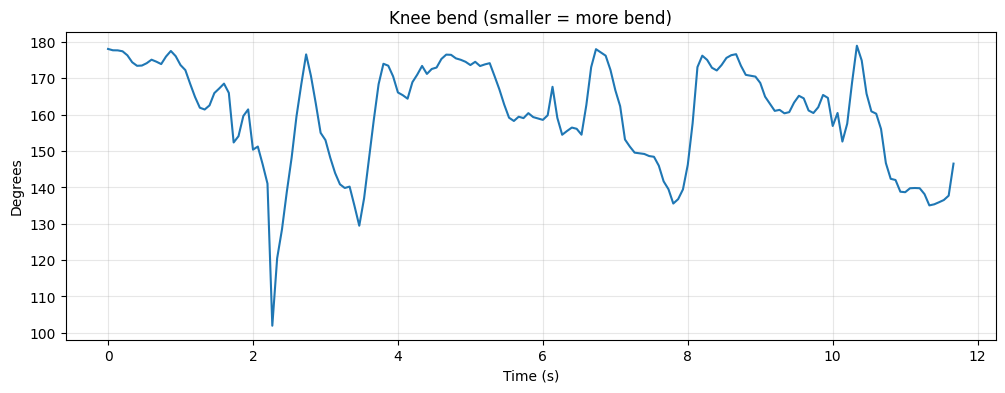

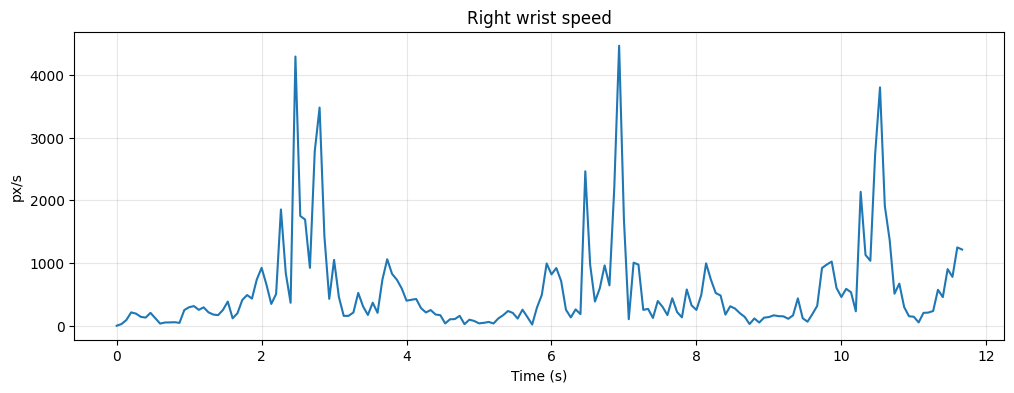

In [ ]:
# 7) Plot key metrics over time (quick sanity check)
def plot_series(time_s: np.ndarray, y: np.ndarray, title: str, ylabel: str):
    plt.figure(figsize=(12, 4))
    plt.plot(time_s, y)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.show()

t = metrics_df["time_s"].to_numpy()

plot_series(t, metrics_df["torso_lean_abs_deg"].to_numpy(), "Torso lean (absolute)", "Degrees")
plot_series(t, metrics_df["stance_width_ratio"].to_numpy(), "Stance width ratio (ankle distance / hip distance)", "Ratio")

knee_min_each = np.nanmin(np.vstack([
    metrics_df["left_knee_angle_deg"].to_numpy(),
    metrics_df["right_knee_angle_deg"].to_numpy(),
]), axis=0)
plot_series(t, knee_min_each, "Knee bend (smaller = more bend)", "Degrees")

if hitting_arm == "LEFT":
    plot_series(t, metrics_df["left_wrist_speed_px_s"].fillna(0).to_numpy(), "Left wrist speed", "px/s")
else:
    plot_series(t, metrics_df["right_wrist_speed_px_s"].fillna(0).to_numpy(), "Right wrist speed", "px/s")

In [ ]:
# 8) Generate AI-based coaching suggestions (rule-based, driven by pose metrics)

def summarize_metrics(metrics_df: pd.DataFrame, strokes_df: pd.DataFrame) -> Dict:
    out = {}
    out["duration_s"] = float(metrics_df["time_s"].max()) if len(metrics_df) else 0.0
    out["frames_processed"] = int(len(metrics_df))

    # Global stats
    knee_min_each = np.nanmin(np.vstack([
        metrics_df["left_knee_angle_deg"].to_numpy(),
        metrics_df["right_knee_angle_deg"].to_numpy(),
    ]), axis=0)
    out["knee_min_deg_global_median"] = float(np.nanmedian(knee_min_each))
    out["torso_lean_abs_deg_global_median"] = float(np.nanmedian(metrics_df["torso_lean_abs_deg"]))
    out["stance_ratio_global_median"] = float(np.nanmedian(metrics_df["stance_width_ratio"]))

    if len(strokes_df):
        out["strokes_detected"] = int(len(strokes_df))
        out["knee_min_deg_at_strokes_median"] = float(np.nanmedian(strokes_df["min_knee_angle_deg"]))
        out["torso_lean_abs_deg_at_strokes_median"] = float(np.nanmedian(strokes_df["torso_lean_abs_deg_med"]))
        out["stance_ratio_at_strokes_median"] = float(np.nanmedian(strokes_df["stance_width_ratio_med"]))
        out["elbow_angle_at_strokes_median"] = float(np.nanmedian(strokes_df["hitting_elbow_angle_deg_med"]))
        out["peak_speed_px_s_median"] = float(np.nanmedian(strokes_df["peak_speed_px_s"]))
    else:
        out["strokes_detected"] = 0

    return out

def generate_suggestions(summary: Dict, hitting_arm: str) -> Tuple[List[str], List[str]]:
    """
    Returns (what_looks_good, focus_next)
    Thresholds are general-purpose and should be tuned for your camera angle & skill level.
    """
    good = []
    focus = []

    # Knee bend
    knee = summary.get("knee_min_deg_at_strokes_median", summary.get("knee_min_deg_global_median", float("nan")))
    if math.isfinite(knee):
        if knee > 155:
            focus.append("**Bend your knees more during the loading phase** before you swing. Aim for a clearly athletic position (often ~120–145° at the knee depending on the shot).")
        elif knee < 110:
            focus.append("You get very low on some swings. If it feels unstable, try **keeping knee bend but staying stacked** (hips under shoulders) instead of collapsing.")
        else:
            good.append("Knee bend looks generally **athletic** on many swings.")

    # Stance width
    stance = summary.get("stance_ratio_at_strokes_median", summary.get("stance_ratio_global_median", float("nan")))
    if math.isfinite(stance):
        if stance < 0.95:
            focus.append("Your base looks narrow at times. Try a **slightly wider stance** (feet a bit farther apart) to improve balance and power transfer.")
        elif stance > 1.9:
            focus.append("Your base can be very wide. For mobility, practice finding a **balanced width** that still lets you rotate and recover quickly.")
        else:
            good.append("Stance width looks **balanced** most of the time.")

    # Torso lean
    lean = summary.get("torso_lean_abs_deg_at_strokes_median", summary.get("torso_lean_abs_deg_global_median", float("nan")))
    if math.isfinite(lean):
        if lean > 22:
            focus.append("You lean your torso a lot during swings. Focus on **staying more centered** and rotating through the shot rather than tipping sideways.")
        else:
            good.append("Torso stays relatively **centered** on many swings.")

    # Elbow (hitting arm)
    elbow = summary.get("elbow_angle_at_strokes_median", float("nan"))
    if math.isfinite(elbow):
        if elbow < 75:
            focus.append(f"Your {hitting_arm.lower()} hitting-arm elbow looks quite bent during fast swings. Work on **creating space** (avoid collapsing) and extend through contact when appropriate.")
        elif elbow > 155:
            focus.append(f"Your {hitting_arm.lower()} hitting arm can look very straight at times. If contact feels late or jammed, practice **relaxed arm + smooth extension** (not locked).")
        else:
            good.append("Hitting-arm elbow position looks **reasonable** on many swings.")

    # Stroke detection confidence
    strokes = summary.get("strokes_detected", 0)
    if strokes < 4:
        focus.append("Only a few swing moments were detected. For best results, use a video where the player is clearly visible, and consider filming from the side with the full body in frame.")

    # General tips (always helpful)
    focus.append("For more accurate feedback, film with: **full body visible**, good lighting, and minimal camera shake; place camera ~hip height and ~side-on to the baseline.")

    return good, focus

summary = summarize_metrics(metrics_df, strokes_df)
good, focus = generate_suggestions(summary, hitting_arm)

report_md = f"""
# Tennis AI Coach Report (Pose-based)

**Video:** `{os.path.basename(meta['video_path'])}`
**Duration analyzed:** {summary['duration_s']:.1f} s
**Frames processed:** {summary['frames_processed']} (stride={meta['sample_stride']})
**Detected swing moments:** {summary['strokes_detected']}

## Snapshot metrics (median)
- Knee bend (smaller = more bend): **{fmt(summary.get('knee_min_deg_at_strokes_median', float('nan')))}°** at swings
- Torso lean (abs): **{fmt(summary.get('torso_lean_abs_deg_at_strokes_median', float('nan')))}°** at swings
- Stance width ratio: **{fmt(summary.get('stance_ratio_at_strokes_median', float('nan')))}** at swings
- Hitting-arm elbow angle: **{fmt(summary.get('elbow_angle_at_strokes_median', float('nan')))}°** (arm guess: {hitting_arm})
- Peak wrist speed: **{fmt(summary.get('peak_speed_px_s_median', float('nan')), 0)} px/s**

## What looks good
{''.join([f'- {x}\n' for x in good]) or '- n/a (insufficient landmarks/visibility in video)'}

## Focus next (highest impact)
{''.join([f'- {x}\n' for x in focus])}
"""

display(Markdown(report_md))



# Tennis AI Coach Report (Pose-based)

**Video:** `IMG_7145_converted.mp4`
**Duration analyzed:** 11.7 s
**Frames processed:** 176 (stride=2)
**Detected swing moments:** 9

## Snapshot metrics (median)
- Knee bend (smaller = more bend): **139.8°** at swings
- Torso lean (abs): **5.5°** at swings
- Stance width ratio: **3.4** at swings
- Hitting-arm elbow angle: **99.4°** (arm guess: RIGHT)
- Peak wrist speed: **1249 px/s**

## What looks good
- Knee bend looks generally **athletic** on many swings.
- Torso stays relatively **centered** on many swings.
- Hitting-arm elbow position looks **reasonable** on many swings.


## Focus next (highest impact)
- Your base can be very wide. For mobility, practice finding a **balanced width** that still lets you rotate and recover quickly.
- For more accurate feedback, film with: **full body visible**, good lighting, and minimal camera shake; place camera ~hip height and ~side-on to the baseline.



In [ ]:
# 9) Save outputs (CSV plus report) and download a ZIP

metrics_csv = os.path.join(OUT_DIR, "metrics.csv")
strokes_csv = os.path.join(OUT_DIR, "strokes.csv")
report_path = os.path.join(OUT_DIR, "report.md")
meta_path = os.path.join(OUT_DIR, "meta.json")

metrics_df.to_csv(metrics_csv, index=False)
strokes_df.to_csv(strokes_csv, index=False)
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_md)

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

# Zip the folder
zip_path = "tennis_ai_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for root, _, files_ in os.walk(OUT_DIR):
        for fn in files_:
            full = os.path.join(root, fn)
            rel = os.path.relpath(full, OUT_DIR)
            z.write(full, arcname=os.path.join("tennis_ai_outputs", rel))

print("Wrote:", metrics_csv)
print("Wrote:", strokes_csv)
if meta.get("annotated_video"):
    print("Wrote:", meta["annotated_video"])
print("Wrote:", report_path)
print("Wrote:", meta_path)
print("ZIP:", zip_path)

from google.colab import files
files.download(zip_path)

Wrote: tennis_ai_outputs/metrics.csv
Wrote: tennis_ai_outputs/strokes.csv
Wrote: tennis_ai_outputs/annotated_video.mp4
Wrote: tennis_ai_outputs/report.md
Wrote: tennis_ai_outputs/meta.json
ZIP: tennis_ai_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>